# 08 Review Summarization
Generate insights, summaries, and actionable feedback from customer reviews.

In [7]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Load all processed data
df = pd.read_csv('../data/cleaned_reviews.csv')
print(f'Loaded {len(df)} reviews')

# Basic statistics

total_reviews = len(df)

positive_count = (df['sentiment'] == 'Positive').sum()
neutral_count = (df['sentiment'] == 'Neutral').sum()
negative_count = (df['sentiment'] == 'Negative').sum()

positive_pct = positive_count / total_reviews * 100
neutral_pct = neutral_count / total_reviews * 100
negative_pct = negative_count / total_reviews * 100

print(f'Total Reviews: {total_reviews}')
print(f'Positive: {positive_count} ({positive_pct:.1f}%)')
print(f'Neutral: {neutral_count} ({neutral_pct:.1f}%)')
print(f'Negative: {negative_count} ({negative_pct:.1f}%)')

Loaded 20370 reviews
Total Reviews: 20370
Positive: 5398 (26.5%)
Neutral: 822 (4.0%)
Negative: 14150 (69.5%)


In [8]:
print(df['sentiment'].value_counts(dropna=False))

sentiment
Negative    14150
Positive     5398
Neutral       822
Name: count, dtype: int64


In [9]:
print(df['sentiment'].unique())

<ArrowStringArray>
['Negative', 'Positive', 'Neutral']
Length: 3, dtype: str


In [10]:
# Extract key phrases (frequent bigrams)
from collections import Counter
import re

all_bigrams = []
for text in df['reviewText_clean']:
    words = text.split()
    bigrams = [' '.join([words[i], words[i+1]]) for i in range(len(words)-1)]
    all_bigrams.extend(bigrams)

top_bigrams = Counter(all_bigrams).most_common(30)

print('\nTop 30 Phrases:')
for i, (phrase, count) in enumerate(top_bigrams, 1):
    print(f'{i:2d}. {phrase:30s} ({count:4d})')


Top 30 Phrases:
 1. customer service               (7094)
 2. amazon prime                   (1503)
 3. amazon customer                (1293)
 4. next day                       (1228)
 5. gift card                      ( 835)
 6. credit card                    ( 774)
 7. day delivery                   ( 749)
 8. prime member                   ( 722)
 9. prime membership               ( 703)
10. money back                     ( 619)
11. even though                    ( 594)
12. amazon com                     ( 574)
13. use amazon                     ( 565)
14. get refund                     ( 555)
15. amazon account                 ( 501)
16. customer support               ( 450)
17. contacted amazon               ( 442)
18. every time                     ( 420)
19. customer services              ( 411)
20. using amazon                   ( 408)
21. love amazon                    ( 393)
22. delivery date                  ( 393)
23. third party                    ( 384)
24. order amazon 

In [12]:
# Sentiment by rating level
sentiment_by_rating = pd.crosstab(
    df['Rating_Num'],
    df['sentiment'],
    normalize='index'
) * 100

print(sentiment_by_rating.round(1))

sentiment   Negative  Neutral  Positive
Rating_Num                             
1.0            100.0      0.0       0.0
2.0            100.0      0.0       0.0
3.0              0.0    100.0       0.0
4.0              0.0      0.0     100.0
5.0              0.0      0.0     100.0


In [16]:
# Review length
df['text_length'] = df['reviewText_clean'].str.split().str.len()

# Long reviews (top 25%)
df['is_long'] = df['text_length'] > df['text_length'].quantile(0.75)

# Long positive reviews
positive_reviews = df[
    (df['sentiment'] == 'Positive') &
    (df['is_long'])
].nlargest(5, 'text_length')

print("Top Positive Reviews")

for _, row in positive_reviews.iterrows():
    print(f"\nRating: {row['Rating_Num']}/5")
    print(f"Length: {row['text_length']} words")
    print(f"Preview: {row['reviewText_clean'][:150]}...")

Top Positive Reviews

Rating: 4.0/5
Length: 370 words
Preview: sheer incompetence displayed part organization never wanting take full responsibility actions especially comes making mistakes gaul nerve accuse lying...

Rating: 5.0/5
Length: 305 words
Preview: weeks ago finally decided take plunge purchase sewing machine know cheap purchase means save dollars buy factory refurbished model sold amazon great r...

Rating: 4.0/5
Length: 292 words
Preview: anyone says amazon screwed fact liar things need approach amazon get good results laziness attitude ignorance lot people name calling venom written ig...

Rating: 5.0/5
Length: 254 words
Preview: user friendly interface vast selectionone commendable features amazon com user friendly interface facilitates effortless browsing shopping experience ...

Rating: 5.0/5
Length: 248 words
Preview: first purchased amazon orders point infrequent sporadic next years kids young however became amazon prime member point started ordering time multiple ...

In [17]:
negative_reviews = df[
    (df['sentiment'] == 'Negative') &
    (df['is_long'])
].nlargest(5, 'text_length')

print("Top Negative Reviews")

for _, row in negative_reviews.iterrows():
    print(f"\nRating: {row['Rating_Num']}/5")
    print(f"Length: {row['text_length']} words")
    print(f"Preview: {row['reviewText_clean'][:150]}...")

Top Negative Reviews

Rating: 1.0/5
Length: 800 words
Preview: company disabled merchants absolutely reason family multiple businesses jewish run story right amazon amazon pay anti semitic company jewish mother be...

Rating: 1.0/5
Length: 666 words
Preview: relation order december placed order amazon around worth items using prime guaranteed next day delivery service order consisted different items range ...

Rating: 1.0/5
Length: 567 words
Preview: honest opinion amazon prime member last decade dealt much garbage amazon become ridiculous bad begin last couple years gotten downright ridiculous thi...

Rating: 1.0/5
Length: 508 words
Preview: back dot com affilaite partner online partner bill gates partner tech finance charity fundraiser website blog amazon com one dot com investor cash fue...

Rating: 1.0/5
Length: 473 words
Preview: amazon thief like sellers worse endorse thieves worst shopping experience ever amazon com big thief sellers seller ripped huawei pro cell phone never ...

In [20]:

# Generate insights summary

insights = {
    'dataset_summary': {
        'total_reviews': int(total_reviews),
        'positive_reviews': int(positive_count),
        'neutral_reviews': int(neutral_count),
        'negative_reviews': int(negative_count),
        'positive_percentage': round(positive_pct, 2),
        'neutral_percentage': round(neutral_pct, 2),
        'negative_percentage': round(negative_pct, 2),
        'average_rating': float(df['Rating_Num'].mean())
    },

    'key_metrics': {
        'avg_review_length': float(df['text_length'].mean()),
        'median_review_length': float(df['text_length'].median()),
        'rating_distribution': df['Rating_Num'].value_counts().sort_index().to_dict()
    },

    'top_phrases': {
        phrase: int(count)
        for phrase, count in top_bigrams[:20]
    },

    'sentiment_analysis': {
        'by_rating': sentiment_by_rating.round(2).to_dict()
    },

    'recommendations': [
        'Focus on Negative reviews to identify recurring customer complaints.',
        'Increase Neutral review samples to improve model balance.',
        f'Current customer satisfaction rate is {positive_pct:.1f}%.',
        'Monitor topic-wise sentiment trends for business insights.',
        'Leverage Positive reviews for testimonials and marketing campaigns.'
    ]
}

print(json.dumps(insights['dataset_summary'], indent=2))

{
  "total_reviews": 20370,
  "positive_reviews": 5398,
  "neutral_reviews": 822,
  "negative_reviews": 14150,
  "positive_percentage": 26.5,
  "neutral_percentage": 4.04,
  "negative_percentage": 69.46,
  "average_rating": 2.1415316642120765
}


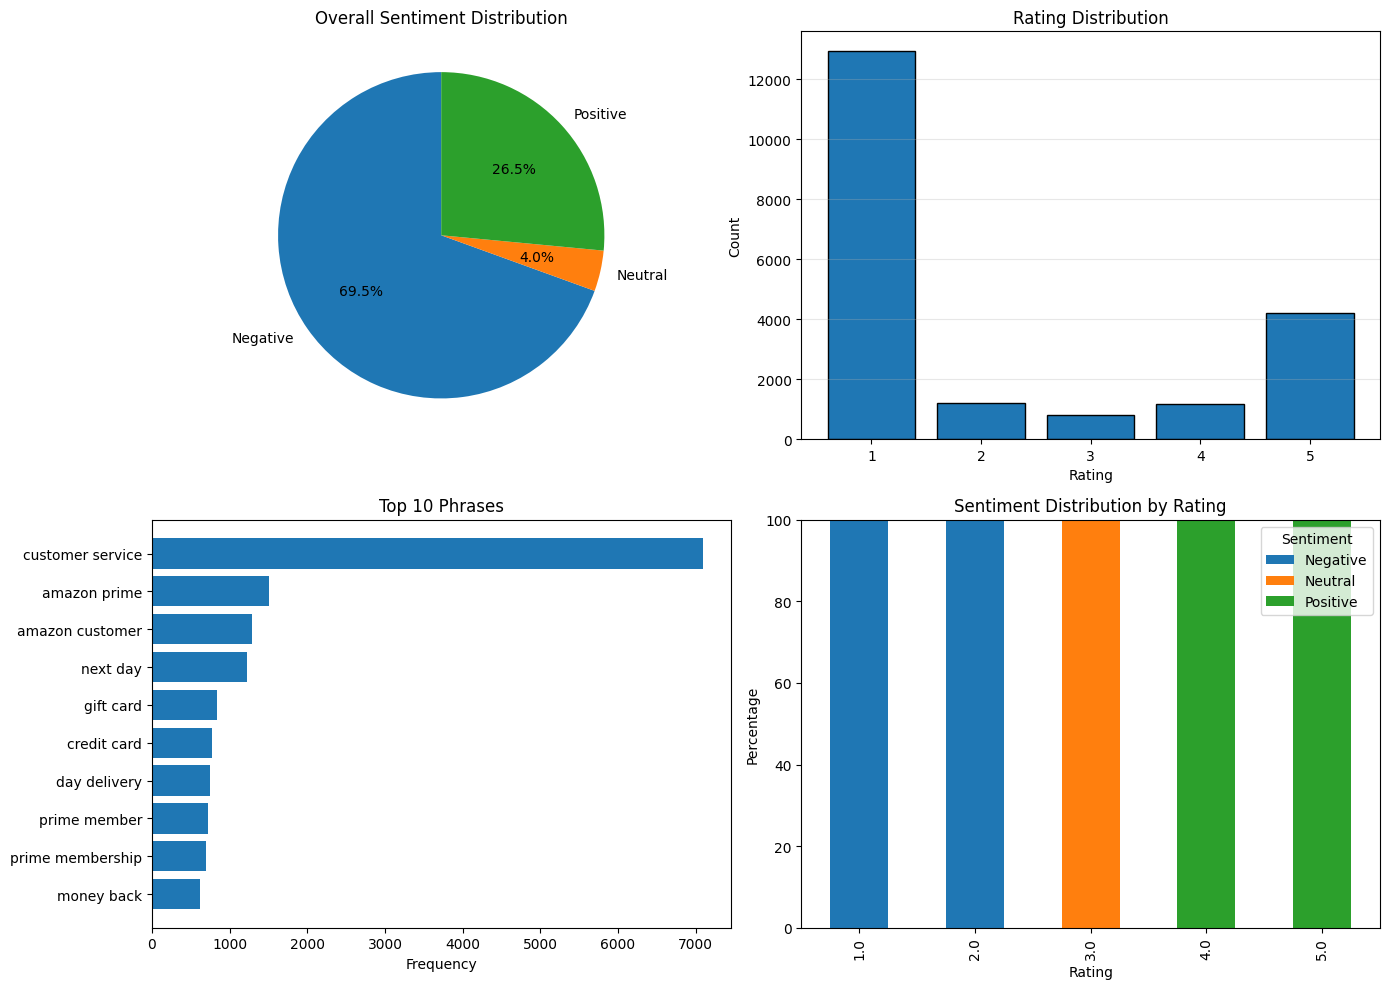

In [21]:
# =========================
# BUSINESS INSIGHTS DASHBOARD
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# Calculate counts
total_reviews = len(df)

positive_count = (df['sentiment'] == 'Positive').sum()
neutral_count = (df['sentiment'] == 'Neutral').sum()
negative_count = (df['sentiment'] == 'Negative').sum()

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------
# 1. Sentiment Distribution
# -------------------------
axes[0, 0].pie(
    [negative_count, neutral_count, positive_count],
    labels=['Negative', 'Neutral', 'Positive'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0, 0].set_title('Overall Sentiment Distribution')

# -------------------------
# 2. Rating Distribution
# -------------------------
rating_counts = df['Rating_Num'].value_counts().sort_index()

axes[0, 1].bar(
    rating_counts.index,
    rating_counts.values,
    edgecolor='black'
)

axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Rating Distribution')
axes[0, 1].grid(axis='y', alpha=0.3)

# -------------------------
# 3. Top 10 Phrases
# -------------------------
top_phrases_list = [p[0] for p in top_bigrams[:10]]
top_counts_list = [p[1] for p in top_bigrams[:10]]

axes[1, 0].barh(
    top_phrases_list,
    top_counts_list
)

axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_title('Top 10 Phrases')
axes[1, 0].invert_yaxis()

# -------------------------
# 4. Sentiment by Rating
# -------------------------
rating_sentiment = pd.crosstab(
    df['Rating_Num'],
    df['sentiment'],
    normalize='index'
) * 100

rating_sentiment.plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Sentiment Distribution by Rating')
axes[1, 1].set_xlabel('Rating')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [22]:
# Save comprehensive report
report_path = '../assets/reports/insights_report.json'
Path(report_path).parent.mkdir(parents=True, exist_ok=True)

with open(report_path, 'w') as f:
    json.dump(insights, f, indent=2, default=str)

print(f'Insights report saved to {report_path}')
print('\n=== FINAL INSIGHTS ===')
for rec in insights['recommendations']:
    print(f'  • {rec}')

Insights report saved to ../assets/reports/insights_report.json

=== FINAL INSIGHTS ===
  • Focus on Negative reviews to identify recurring customer complaints.
  • Increase Neutral review samples to improve model balance.
  • Current customer satisfaction rate is 26.5%.
  • Monitor topic-wise sentiment trends for business insights.
  • Leverage Positive reviews for testimonials and marketing campaigns.


In [24]:
# Export processed data sample

sample_output = df[
    ['reviewText_clean', 'Rating_Num', 'sentiment', 'text_length']
].head(100)

sample_path = '../assets/reports/processed_reviews_sample.csv'
sample_output.to_csv(sample_path, index=False)

print(f'Sample processed reviews exported to {sample_path}')

print('\nDataset Summary:')

print(f'  Total records: {len(df)}')

print(f'  Positive: {(df["sentiment"] == "Positive").sum()}')
print(f'  Neutral : {(df["sentiment"] == "Neutral").sum()}')
print(f'  Negative: {(df["sentiment"] == "Negative").sum()}')

print(f'  Average rating: {df["Rating_Num"].mean():.2f}/5')

print(f'  Average review length: {df["text_length"].mean():.1f} words')

Sample processed reviews exported to ../assets/reports/processed_reviews_sample.csv

Dataset Summary:
  Total records: 20370
  Positive: 5398
  Neutral : 822
  Negative: 14150
  Average rating: 2.14/5
  Average review length: 41.8 words
